[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leaguilar/fit_2026/blob/main/notebooks/3_modelos_de_lenguaje.ipynb)

# 3. Modelos de lenguaje: de Eliza a un LLM

**Taller Hands-On AI | FIT 2026**

Un modelo de lenguaje hace **una sola cosa**: dado un trozo de texto,
predice qué palabra viene después. Todo lo demás sale de ahí.

Vamos a construirlo tres veces, igual que hicimos con el agente:
primero con **reglas**, después con una **tabla**, y al final con una **red**.

| Parte | Qué hacemos |
|---|---|
| 1 | Eliza (1966): parece que entiende, y son 30 reglas. |
| 2 | Contar pares de palabras: otra tabla (**hoja de trabajo**). |
| 3 | La tabla se rompe igual que la Q-table. |
| 4 | Una red neuronal de lenguaje, entrenada aquí mismo. |
| 5 | Un LLM preentrenado: las mismas probabilidades, a otra escala. |

In [1]:
# --- Setup. Ejecuta esta celda PRIMERO: empieza a bajar el modelo en segundo
#     plano mientras trabajamos en las otras partes. ---
import os, subprocess, sys
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # sin avisos de TensorFlow
os.environ["USE_TF"] = "0"                 # transformers no toca TensorFlow
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers", "accelerate"], check=False)

import re, time, threading
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9
# Los tonos estan elegidos para que se distingan tambien con daltonismo
# rojo-verde (comprobado por script, no a ojo).
AZUL   = "#215CAF"
ROJO   = "#B7352D"
VERDE  = "#8E9C1E"
PETROL = "#00A0C6"
GRIS   = "#6F6F6F"

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass
from ipywidgets import interact, FloatSlider, Dropdown, IntSlider

# El modelo de la parte 5. Descomenta el que quieras usar.
MODELO = "Qwen/Qwen3-0.6B"                    # ~1.5 GB, anda en CPU
# MODELO = "Qwen/Qwen2.5-0.5B-Instruct"       # mas pequeno todavia
# MODELO = "Qwen/Qwen3-1.7B"                  # mejor, pero pide GPU

def _bajar():
    try:
        from huggingface_hub import snapshot_download
        snapshot_download(MODELO)
    except Exception as e:
        print("(la descarga en segundo plano fallo, se hara mas tarde)", e)

threading.Thread(target=_bajar, daemon=True).start()
print(f"Bajando {MODELO} en segundo plano. Sigue con la parte 1.")

Bajando Qwen/Qwen3-0.6B en segundo plano. Sigue con la parte 1.


---
## 1. Eliza (1966): la ilusión con 30 reglas

Eliza fue el primer programa que la gente confundió con una persona. No
aprende nada, no tiene memoria y no entiende una palabra. Solo:

1. Busca una **palabra clave** en lo que le dices.
2. Parte la frase con un **patrón** (`* me molesta *`).
3. Devuelve una **plantilla**, cambiando "yo" por "tú".

Nada más. Y funciona.

In [2]:
# Cambiar los pronombres es lo que hace que la respuesta suene dirigida a ti.
PRONOMBRES = {
    "yo": "tu", "tu": "yo", "me": "te", "te": "me", "mi": "tu", "mis": "tus",
    "tus": "mis", "mio": "tuyo", "tuyo": "mio", "conmigo": "contigo",
    "contigo": "conmigo", "soy": "eres", "eres": "soy", "estoy": "estas",
    "estas": "estoy", "tengo": "tienes", "tienes": "tengo", "quiero": "quieres",
}

def sin_tildes(s):
    tabla = str.maketrans("áéíóúüÁÉÍÓÚÜ", "aeiouuAEIOUU")
    return s.translate(tabla)

def reflejar(frase):
    return " ".join(PRONOMBRES.get(p, p) for p in sin_tildes(frase.lower()).split())

# Cada entrada: palabra clave -> (rango, [(patron, [respuestas])])
# El patron usa * como comodin. {1} es lo que capturo el primer comodin.
GUION = {
    "madre":  (5, [("*", ["Cuentame mas sobre tu familia.",
                          "¿Que mas recuerdas de tu madre?"])]),
    "padre":  (5, [("*", ["Cuentame mas sobre tu padre.",
                          "¿Como te llevas con el?"])]),
    "sueno":  (5, [("*", ["¿Que crees que significa ese sueno?",
                          "¿Suenas a menudo con eso?"])]),
    "quiero": (4, [("* quiero *", ["¿Que harias si consiguieras {2}?",
                                   "¿Por que quieres {2}?"])]),
    "soy":    (4, [("* soy *", ["¿Desde cuando eres {2}?",
                                "¿Como te hace sentir ser {2}?"])]),
    "estoy":  (4, [("* estoy *", ["¿Por que estas {2}?",
                                  "¿Y desde cuando estas {2}?"])]),
    "siento": (4, [("* siento *", ["¿Por que te sientes {2}?",
                                   "¿Y desde cuando te sientes {2}?"])]),
    "comida": (4, [("*", ["Cuentame mas de esa comida.",
                          "¿Y eso te gusta de verdad?"])]),
    "amigos": (4, [("*", ["Cuentame mas de tus amigos.",
                          "¿Que esperas de tus amigos?"])]),
    "porque": (3, [("*", ["¿De verdad crees que esa es la razon?",
                          "¿Y que otra razon se te ocurre?"])]),
    "siempre":(3, [("*", ["¿Siempre? ¿Puedes darme un ejemplo?",
                          "¿En serio siempre?"])]),
    "no":     (2, [("*", ["¿Por que no?", "¿Estas seguro de que no?"])]),
    "tu":     (3, [("* tu *", ["¿Por que te importa si yo {2}?",
                               "Estabamos hablando de ti, no de mi."])]),
    "": (0, [("*", ["Cuentame mas.",
                    "Ya veo. ¿Y como te sientes con eso?",
                    "¿Que quieres decir exactamente con eso?",
                    "Sigue, te escucho."])]),
}

def encajar(patron, frase):
    """Convierte '* quiero *' en una expresion regular y devuelve los trozos."""
    partes = [re.escape(t.strip()) for t in patron.split("*")]
    m = re.fullmatch(r"\s*(.*?)\s*".join(partes).strip() or ".*", frase.strip())
    return list(m.groups()) if m else None

class Eliza:
    def __init__(self, guion, semilla=0):
        self.guion = guion
        self.rng = np.random.default_rng(semilla)
        self.historia = []

    def responder(self, texto):
        limpio = sin_tildes(texto.lower())
        limpio = re.sub(r"[^\w\s]", "", limpio)
        # De todas las claves presentes, gana la de mayor rango.
        claves = [k for k in self.guion if k and k in limpio.split()]
        clave = max(claves, key=lambda k: self.guion[k][0]) if claves else ""
        for patron, respuestas in self.guion[clave][1]:
            trozos = encajar(patron, limpio)
            if trozos is not None:
                r = respuestas[int(self.rng.integers(len(respuestas)))]
                for i, t in enumerate(trozos, start=1):
                    r = r.replace("{%d}" % i, reflejar(t) or "eso")
                self.historia.append((texto, r, clave or "(ninguna)"))
                return r
        return "Cuentame mas."

eliza = Eliza(GUION)
for frase in ["Quiero comer pizza",
              "Mi madre cocina muy bien",
              "Estoy aburrido los domingos",
              "No me gusta la sopa",
              "Tu no me entiendes"]:
    print(f"TU    : {frase}")
    print(f"ELIZA : {eliza.responder(frase)}\n")

TU    : Quiero comer pizza
ELIZA : ¿Por que quieres comer pizza?

TU    : Mi madre cocina muy bien
ELIZA : ¿Que mas recuerdas de tu madre?

TU    : Estoy aburrido los domingos
ELIZA : ¿Y desde cuando estas aburrido los domingos?

TU    : No me gusta la sopa
ELIZA : ¿Por que no?

TU    : Tu no me entiendes
ELIZA : ¿Por que te importa si yo no te entiendes?



In [3]:
# ¿Que palabra clave disparo cada respuesta? Aqui se ve el truco entero.
print(f"{'lo que dijiste':34s} {'clave':10s} respuesta")
print("-" * 100)
for dicho, resp, clave in eliza.historia:
    print(f"{dicho[:33]:34s} {clave:10s} {resp}")
print("\nNo hay comprension. Hay una palabra clave y una plantilla.")

lo que dijiste                     clave      respuesta
----------------------------------------------------------------------------------------------------
Quiero comer pizza                 quiero     ¿Por que quieres comer pizza?
Mi madre cocina muy bien           madre      ¿Que mas recuerdas de tu madre?
Estoy aburrido los domingos        estoy      ¿Y desde cuando estas aburrido los domingos?
No me gusta la sopa                no         ¿Por que no?
Tu no me entiendes                 tu         ¿Por que te importa si yo no te entiendes?

No hay comprension. Hay una palabra clave y una plantilla.


In [4]:
# Habla tu con ella. Escribe 'salir' para terminar.
# (Si ejecutas el notebook sin teclado, esta celda simplemente se salta.)
charla = Eliza(GUION, semilla=1)
print("ELIZA: Buenas. Cuentame que tal va tu dia.")
try:
    while True:
        tuyo = input("TU: ")
        if tuyo.strip().lower() in ("salir", "adios", "chau", ""):
            print("ELIZA: Hasta luego.")
            break
        print("ELIZA:", charla.responder(tuyo))
except Exception:
    print("(sin teclado disponible, seguimos)")

ELIZA: Buenas. Cuentame que tal va tu dia.
(sin teclado disponible, seguimos)


---
## 2. Predecir la siguiente palabra es contar pares

Eliza no predice nada. Un modelo de lenguaje sí: mira las palabras que ya
hay y elige la siguiente.

La forma más simple de hacerlo es **contar**. Recorremos un texto y
apuntamos, para cada palabra, qué palabras vinieron después y cuántas
veces. Eso es un **bigrama**.

### A mano (5 minutos, hoja de trabajo)

Nuestro texto son cuatro frases: dos animales, dos verbos, dos comidas.

> *el gato come pescado · el gato bebe agua · el perro come carne · el perro bebe agua*

En la hoja de trabajo llenas **dos** tablas y comparas:

1. Con **una** palabra de contexto (bigramas). Después de `come`, ¿qué viene?
2. Con **dos** palabras (trigramas). Después de `gato come`, ¿ahora lo sabes?

La celda de abajo da las dos respuestas, y de paso mide lo que importa: cuántas
opciones quedan en cada fila según cuánto contexto mires.

In [ ]:
frase = ("el gato come pescado el gato bebe agua "
         "el perro come carne el perro bebe agua")
palabras_frase = frase.split()

def tabla_a_mano(n):
    """Cuenta que sigue a cada contexto de n-1 palabras."""
    tabla = defaultdict(Counter)
    for i in range(len(palabras_frase) - n + 1):
        contexto = tuple(palabras_frase[i:i + n - 1])
        tabla[contexto][palabras_frase[i + n - 1]] += 1
    return tabla

for n in (2, 3, 4):
    tabla = tabla_a_mano(n)
    opciones = [len(v) for v in tabla.values()]
    print(f"=== {n}-grama: {n-1} palabra(s) de contexto ===")
    for contexto in sorted(tabla):
        total = sum(tabla[contexto].values())
        sigue = "   ".join(f"{b} {c}/{total}" for b, c in tabla[contexto].most_common())
        marca = "  <-- AMBIGUO" if len(tabla[contexto]) > 1 else ""
        print(f"  tras {' '.join(contexto):16s} -> {sigue}{marca}")
    print(f"  {len(tabla)} filas, {sum(opciones)/len(opciones):.2f} opciones por fila "
          f"de media, maximo {max(opciones)}\n")

print("Mas contexto quita dudas, pero deja menos ejemplos por fila.")
print("Con 3 palabras de contexto ninguna fila tiene mas de una opcion:")
print("el modelo ya no puede hacer otra cosa que COPIAR el texto.")

Fíjate en la forma: **una fila por contexto, y en cada fila un número por
cada palabra posible.** Es la misma forma que la Q-table del notebook 2.
Y se va a romper por la misma razón.

In [6]:
# Ahora con un texto de verdad: el Quijote.
import urllib.request, os
URL = ("https://raw.githubusercontent.com/leaguilar/fit_2026/main/"
       "datos/quijote_fragmento.txt")
# Si ya tienes el repo clonado, usa el archivo local. En Colab lo baja.
CANDIDATOS = ["quijote_fragmento.txt", "datos/quijote_fragmento.txt",
              "../datos/quijote_fragmento.txt"]
RUTA = next((c for c in CANDIDATOS if os.path.exists(c)), None)
if RUTA is None:
    RUTA = "quijote_fragmento.txt"
    urllib.request.urlretrieve(URL, RUTA)
print("corpus:", RUTA)

crudo = open(RUTA, encoding="utf-8").read()
crudo = "".join(l for l in crudo.splitlines(keepends=True) if not l.startswith("#"))
palabras = re.findall(r"\w+|[.,;:!?¡¿]", crudo.lower())

corte = int(len(palabras) * 0.9)
entrenamiento, prueba = palabras[:corte], palabras[corte:]
print(f"{len(palabras):,} palabras   {len(set(palabras)):,} distintas")
print(f"entrenamiento {len(entrenamiento):,}   prueba {len(prueba):,}")
print("\n" + " ".join(palabras[:30]))

corpus: quijote_fragmento.txt
83,669 palabras   8,701 distintas
entrenamiento 75,302   prueba 8,367

en un lugar de la mancha , de cuyo nombre no quiero acordarme , no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero , adarga


In [7]:
# Vocabulario: nos quedamos con las 5000 palabras mas frecuentes.
VOCAB = 5000
comunes = [p for p, _ in Counter(entrenamiento).most_common(VOCAB - 1)]
a_num = {p: i + 1 for i, p in enumerate(comunes)}
a_num["<desconocida>"] = 0
a_pal = {i: p for p, i in a_num.items()}

ent = np.array([a_num.get(p, 0) for p in entrenamiento])
pru = np.array([a_num.get(p, 0) for p in prueba])
print(f"El vocabulario de {VOCAB} palabras cubre el "
      f"{100*(ent>0).mean():.1f}% del texto.")

def tabla_ngramas(n, ids):
    """Una fila por contexto de n-1 palabras."""
    tabla = defaultdict(Counter)
    for i in range(len(ids) - n + 1):
        tabla[tuple(ids[i:i + n - 1])][ids[i + n - 1]] += 1
    return tabla

tablas = {n: tabla_ngramas(n, ent) for n in (2, 3, 4)}
for n, t in tablas.items():
    print(f"{n}-grama: {len(t):>7,} filas en la tabla")

El vocabulario de 5000 palabras cubre el 95.8% del texto.
2-grama:   5,000 filas en la tabla
3-grama:  31,623 filas en la tabla
4-grama:  57,771 filas en la tabla


In [8]:
def generar_ngrama(n, semilla="en un lugar de la mancha", palabras_nuevas=30, rng=None):
    rng = rng or np.random.default_rng(0)
    tabla = tablas[n]
    salida = [a_num.get(p, 0) for p in semilla.split()]
    for _ in range(palabras_nuevas):
        ctx = tuple(salida[-(n - 1):])
        fila = tabla.get(ctx)
        if not fila:
            break
        # Quitamos <desconocida> (indice 0): distrae y no ensena nada.
        util = {k: v for k, v in fila.items() if k != 0}
        if not util:
            break
        opciones, pesos = zip(*util.items())
        pesos = np.array(pesos, dtype=float); pesos /= pesos.sum()
        salida.append(int(rng.choice(opciones, p=pesos)))
    return " ".join(a_pal[i] for i in salida)

for n in (2, 3, 4):
    print(f"--- {n}-grama ---")
    print(generar_ngrama(n), "\n")

--- 2-grama ---
en un lugar de la mancha y en su autor arábigo y denuedo y su mismo ? ¡ hablara en verdad que sabes . en razón de los hábitos largos que jamás hago lo había hallado 

--- 3-grama ---
en un lugar de la mancha y contalle punto por punto , los doce pares dejar , tan grande peligro en que ahora nos ha de valer al hijo la bondad de su caballero sino en 

--- 4-grama ---
en un lugar de la mancha el mío ; que , pues aquel camino era real , a una o dos leguas , de buena gana y sin apremio alguno confesaremos la verdad que la fama 



El bigrama suelta palabras que casi encajan. El trigrama suena mejor. Y el
4-grama suena casi bien... porque está **copiando** el Quijote.

Eso se mide: cortamos lo generado en trozos de 5 palabras y contamos cuántos
aparecen tal cual en el texto de entrenamiento.

In [9]:
quintetos = set(tuple(entrenamiento[i:i + 5]) for i in range(len(entrenamiento) - 5))

def fraccion_copiada(texto):
    trozos = texto.split()
    total = max(len(trozos) - 5, 1)
    copiados = sum(tuple(trozos[i:i + 5]) in quintetos for i in range(total))
    return 100 * copiados / total

for n in (2, 3, 4):
    texto = generar_ngrama(n, palabras_nuevas=200, rng=np.random.default_rng(1))
    print(f"{n}-grama: {fraccion_copiada(texto):5.1f}% de lo que escribe esta "
          f"copiado literalmente del libro")

2-grama:   3.0% de lo que escribe esta copiado literalmente del libro
3-grama:  35.7% de lo que escribe esta copiado literalmente del libro
4-grama: 100.0% de lo que escribe esta copiado literalmente del libro


El 4-grama no aprendió el idioma: memorizó el libro.

Ahora midámoslo de otra forma, con la **perplexity**.

> **Perplexity**: entre cuántas palabras distintas duda el modelo en cada paso.
> Si dudara por igual entre 100 palabras, su perplexity sería 100. Si estuviera
> seguro de una sola, sería 1. **Menos es mejor.**

Se calcula sobre texto que el modelo **nunca vio**: aquí, el último 10% del
Quijote. Si la midiéramos sobre el texto de entrenamiento, un modelo que
memoriza saldría perfecto, y eso no nos dice nada.

In [10]:
def perplexity(n, ids_prueba, alpha=0.1):
    tabla = tablas[n]
    log_p, N = 0.0, 0
    for i in range(len(ids_prueba) - n + 1):
        ctx = tuple(ids_prueba[i:i + n - 1]); w = ids_prueba[i + n - 1]
        fila = tabla.get(ctx)
        total = (sum(fila.values()) + alpha * VOCAB) if fila else alpha * VOCAB
        p = ((fila[w] if fila else 0) + alpha) / total
        log_p += np.log(p); N += 1
    return float(np.exp(-log_p / N))

pp_ngrama = {n: perplexity(n, pru) for n in (2, 3, 4)}
for n in (2, 3, 4):
    print(f"{n}-grama: {len(tablas[n]):>7,} filas   perplexity {pp_ngrama[n]:8.1f}")

2-grama:   5,000 filas   perplexity    292.6
3-grama:  31,623 filas   perplexity   1513.7
4-grama:  57,771 filas   perplexity   3623.1


Más contexto **empeora** el resultado. Es exactamente el problema del
notebook 2: al afinar la tabla, cada fila se queda con casi ningún ejemplo,
y la mayoría de los contextos de prueba nunca aparecieron en el
entrenamiento.

La tabla no generaliza. Solo recuerda.

---
## 4. Una red neuronal de lenguaje

Cambiamos la tabla por una red, igual que en el notebook 2.

La red mira las **4 palabras anteriores**, las convierte en vectores
(*embeddings*), los pasa por una capa escondida y saca una probabilidad
para cada una de las 5000 palabras del vocabulario.

Se entrena con gradient descent y backpropagation. Lo mismo del
notebook 0 y 1, sin ningún truco nuevo.

In [11]:
import torch
import torch.nn as nn

CONTEXTO = 4

class RedDeLenguaje(nn.Module):
    def __init__(self, vocab=VOCAB, dim=48, escondida=256, contexto=CONTEXTO):
        super().__init__()
        self.emb = nn.Embedding(vocab, dim)           # una palabra -> un vector
        self.mlp = nn.Sequential(
            nn.Linear(contexto * dim, escondida), nn.Tanh(),
            nn.Linear(escondida, vocab))              # -> puntaje por palabra
    def forward(self, x):
        return self.mlp(self.emb(x).flatten(1))

def a_ejemplos(ids):
    X = np.stack([ids[i:i + CONTEXTO] for i in range(len(ids) - CONTEXTO)])
    return torch.tensor(X), torch.tensor(ids[CONTEXTO:])

Xe, Ye = a_ejemplos(ent)
Xp, Yp = a_ejemplos(pru)
red = RedDeLenguaje()
print(f"{sum(q.numel() for q in red.parameters()):,} parametros")
print(f"{len(Xe):,} ejemplos de entrenamiento")

1,574,408 parametros
75,298 ejemplos de entrenamiento


In [12]:
# Entrenamiento: unos 30 segundos en CPU.
torch.manual_seed(0)
opt = torch.optim.Adam(red.parameters(), lr=2e-3)
sub = torch.randperm(len(Xp))[:4000]          # muestra de prueba, para ir rapido
curva = []
t0 = time.time()
for epoca in range(5):
    orden = torch.randperm(len(Xe))
    for i in range(0, len(Xe), 512):
        lote = orden[i:i + 512]
        perdida = nn.functional.cross_entropy(red(Xe[lote]), Ye[lote])
        opt.zero_grad(); perdida.backward(); opt.step()
    with torch.no_grad():
        pv = float(nn.functional.cross_entropy(red(Xp[sub]), Yp[sub]))
    curva.append(np.exp(pv))
    print(f"  epoca {epoca}: perplexity de prueba {curva[-1]:7.1f}   ({time.time()-t0:.0f}s)")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

  epoca 0: perplexity de prueba   165.0   (13s)
  epoca 1: perplexity de prueba   139.9   (22s)
  epoca 2: perplexity de prueba   134.0   (30s)
  epoca 3: perplexity de prueba   136.0   (38s)
  epoca 4: perplexity de prueba   143.4   (47s)


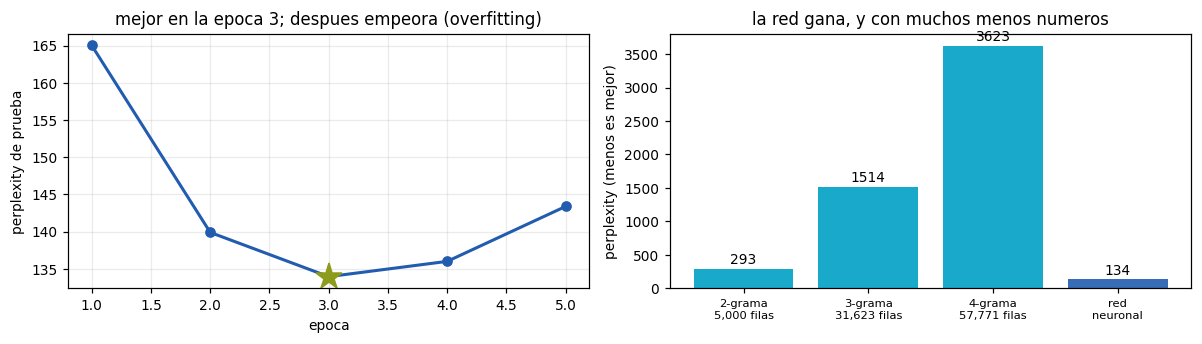

Numeros en la tabla del 4-grama : 288,855,000
Numeros en la red              : 1,574,408
La red usa 183 veces menos numeros y acierta mas.


In [13]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))

a1.plot(range(1, len(curva) + 1), curva, "o-", color=AZUL, lw=2)
mejor = int(np.argmin(curva))
a1.plot(mejor + 1, curva[mejor], "*", color=VERDE, ms=18)
a1.set_xlabel("epoca"); a1.set_ylabel("perplexity de prueba")
a1.grid(alpha=.25)
a1.set_title(f"mejor en la epoca {mejor+1}; despues empeora (overfitting)")

nombres = [f"{n}-grama\n{len(tablas[n]):,} filas" for n in (2, 3, 4)] + ["red\nneuronal"]
valores = [pp_ngrama[n] for n in (2, 3, 4)] + [min(curva)]
a2.bar(nombres, valores, color=[PETROL] * 3 + [AZUL], alpha=.9)
for i, v in enumerate(valores):
    a2.text(i, v + max(valores) * .02, f"{v:.0f}", ha="center", fontsize=9)
a2.set_ylabel("perplexity (menos es mejor)")
a2.set_title("la red gana, y con muchos menos numeros")
a2.tick_params(axis="x", labelsize=7.5)
plt.tight_layout(); plt.show()

filas_4 = len(tablas[4]) * VOCAB
print(f"Numeros en la tabla del 4-grama : {filas_4:,}")
print(f"Numeros en la red              : {sum(q.numel() for q in red.parameters()):,}")
print(f"La red usa {filas_4/sum(q.numel() for q in red.parameters()):.0f} veces menos numeros y acierta mas.")

In [24]:
def generar_red(semilla="en un lugar de la mancha", palabras_nuevas=35, temperatura=0.8, rng=None):
    rng = rng or np.random.default_rng(0)
    ctx = [a_num.get(p, 0) for p in semilla.split()][-CONTEXTO:]
    ctx = [0] * (CONTEXTO - len(ctx)) + ctx
    salida = semilla.split()
    for _ in range(palabras_nuevas):
        with torch.no_grad():
            logits = red(torch.tensor([ctx]))[0] / max(temperatura, 1e-3)
        p = torch.softmax(logits, -1).numpy()
        p[0] = 0.0                     # nunca elegimos <desconocida>
        p /= p.sum()
        j = int(rng.choice(len(p), p=p))
        salida.append(a_pal[j]); ctx = ctx[1:] + [j]
    return " ".join(salida)

def ver_temperatura(temperatura=0.8):
    print(f"temperatura = {temperatura}\n")
    print(generar_red(temperatura=temperatura, rng=np.random.default_rng(0)))

interact(ver_temperatura,
         temperatura=FloatSlider(value=0.8, min=0.1, max=1.6, step=.1,
                                 description="temperatura", continuous_update=False))

interactive(children=(FloatSlider(value=0.8, continuous_update=False, description='temperatura', max=1.6, min=…

<function __main__.ver_temperatura(temperatura=0.8)>

La **temperatura** decide cuánto arriesga el modelo. Cerca de 0 elige
siempre la palabra más probable y se repite. Por encima de 1 se vuelve
creativo y luego incoherente.

Es el mismo deslizador que traen ChatGPT y compañía.

---
## 5. Un LLM de verdad

Nuestra red tiene 1.5 millones de perillas y leyó medio Quijote. Un modelo
como el que vamos a cargar tiene **600 millones** y leyó una parte enorme
de internet.

La arquitectura cambia (es un *transformer*, no un MLP), pero la tarea es
**idéntica**: dado el texto de antes, ¿qué palabra viene ahora?

In [15]:
from transformers import AutoTokenizer, AutoModelForCausalLM

t0 = time.time()
tok = AutoTokenizer.from_pretrained(MODELO)
llm = AutoModelForCausalLM.from_pretrained(MODELO, dtype=torch.float32).eval()
print(f"{MODELO} cargado en {time.time()-t0:.0f}s")
print(f"{sum(q.numel() for q in llm.parameters())/1e6:.0f} millones de parametros")
print(f"vocabulario: {len(tok)} tokens")

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

Qwen/Qwen3-0.6B cargado en 7s
596 millones de parametros
vocabulario: 151669 tokens


In [16]:
def siguientes_tokens(texto, k=10):
    ids = tok(texto, return_tensors="pt")
    with torch.no_grad():
        logits = llm(**ids).logits[0, -1]
    p = torch.softmax(logits, -1)
    top = torch.topk(p, k)
    return [tok.decode([i]) for i in top.indices], top.values.numpy()

def barras_siguiente(texto):
    nombres, probs = siguientes_tokens(texto)
    fig, ax = plt.subplots(figsize=(7, 2.8))
    ax.barh([repr(n) for n in nombres][::-1], probs[::-1], color=AZUL, alpha=.9)
    ax.set_xlabel("probabilidad"); ax.set_title(f'despues de: "{texto}"')
    for i, v in enumerate(probs[::-1]):
        ax.text(v + .005, i, f"{100*v:.1f}%", va="center", fontsize=8)
    plt.tight_layout(); plt.show()

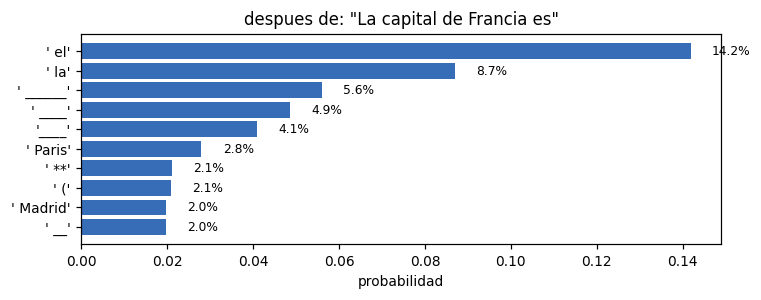

In [17]:
barras_siguiente("La capital de Francia es")

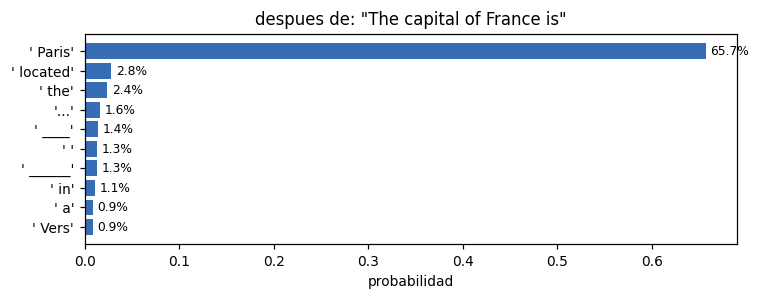

In [18]:
barras_siguiente("The capital of France is")

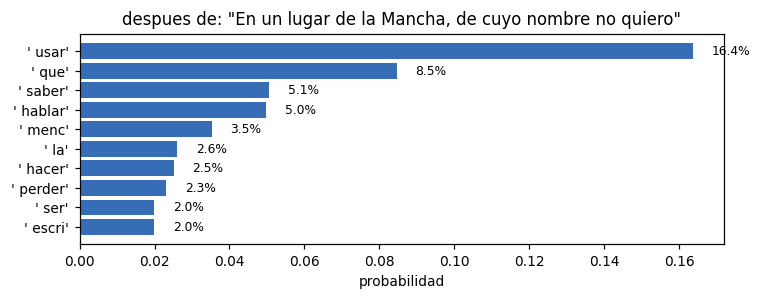

In [19]:
barras_siguiente("En un lugar de la Mancha, de cuyo nombre no quiero")

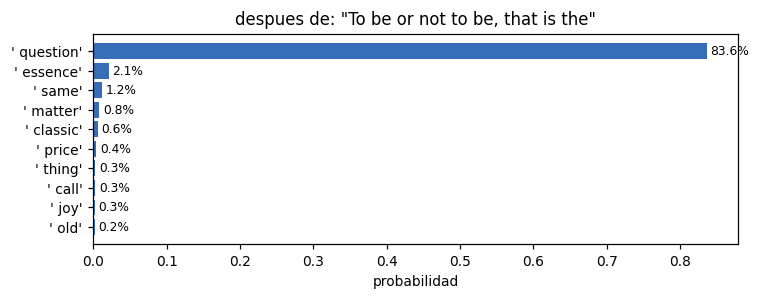

In [25]:
barras_siguiente("To be or not to be, that is the")

Es exactamente lo que hacía nuestra tabla de bigramas, con dos diferencias:
el contexto no son 4 palabras sino miles, y los números no salieron de
contar sino de gradient descent sobre una montaña de texto.

De ahí en adelante todo es **muestrear una palabra y repetir**.

In [21]:
def escribir(prompt="Habia una vez un robot que", n=60, temperatura=0.8):
    ids = tok(prompt, return_tensors="pt")
    with torch.no_grad():
        salida = llm.generate(**ids, max_new_tokens=n, do_sample=temperatura > 0.01,
                              temperature=max(temperatura, 0.01), top_p=0.95,
                              pad_token_id=tok.eos_token_id)
    print(tok.decode(salida[0], skip_special_tokens=True))

for t in [0.2, 0.8, 1.5]:
    print(f"=== temperatura {t} ===")
    escribir(temperatura=t)
    print()

=== temperatura 0.2 ===
Habia una vez un robot que se llamaba "El Tercer", y este robot se encargaba de ayudar a la humanidad en la búsqueda de recursos naturales. El Tercer se encargaba de ayudar a la humanidad en la búsqueda de recursos naturales. El Tercer se enc

=== temperatura 0.8 ===
Habia una vez un robot que lo había hecho. El robot lo había hecho con la ayuda de una persona que no lo había visto. Por eso, el robot no lo había visto, y lo había hecho con la ayuda de una persona que no lo había visto. ¿Qué quiere decir "quien" en el texto?

En

=== temperatura 1.5 ===
Habia una vez un robot que tenía una vida y un ser quería saber a que debe servirle.

Translate to Portuguese.

The robot had a life and a service that it wished to fulfill.
I think, in Portuguese, this sentence should be translated.

**Answer:
The robot had a life, and desired to serve.



---
## Resumen

1. **Eliza** finge con reglas. No predice nada.
2. Un modelo de lenguaje **predice la siguiente palabra**, y la forma más
   simple de hacerlo es contar pares: una tabla.
3. Esa tabla se rompe igual que la Q-table: con más contexto tiene más
   filas, menos ejemplos por fila, y acaba memorizando en vez de aprender.
4. Una **red** aprende una función del contexto, generaliza, y gana usando
   muchísimos menos números.
5. Un **LLM** es lo mismo, con más contexto, más datos y más perillas.

En el último notebook vemos qué aparece cuando eso se hace **muy** grande:
cosas que nadie programó y que la red no tenía por qué saber hacer.